# CKD Prediction — EDA
### Chronic Kidney Disease Dataset Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
RANDOM_STATE = 42

print("Libraries loaded ✓")

Libraries loaded ✓


In [4]:
df = pd.read_csv("data/kidney_disease.csv")
print("Shape:", df.shape)
df.head(3)

import os
os.makedirs('../report', exist_ok=True)
print("Report folder ready ✓")

Shape: (399, 25)
Report folder ready ✓


In [5]:
print("=== Data Types & Non-Null Counts ===")
print(df.info())
print("\n=== Statistical Summary ===")
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     390 non-null    float64
 1   bp      387 non-null    float64
 2   sg      352 non-null    float64
 3   al      353 non-null    float64
 4   su      350 non-null    float64
 5   rbc     247 non-null    object 
 6   pc      334 non-null    object 
 7   pcc     395 non-null    object 
 8   ba      395 non-null    object 
 9   bgr     355 non-null    float64
 10  bu      380 non-null    float64
 11  sc      382 non-null    float64
 12  sod     312 non-null    float64
 13  pot     311 non-null    float64
 14  hemo    347 non-null    float64
 15  pcv     328 non-null    float64
 16  wbcc    293 non-null    float64
 17  rbcc    268 non-null    float64
 18  htn     397 non-null    object 
 19  dm      397 non-null    object 
 20  cad     397 non-null    object 
 21  ap

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,390.000000,387.000000,352.000000,353.000000,350.000000,355.000000,380.000000,382.000000,312.000000,311.000000,347.000000,328.000000,293.000000,268.000000
mean,51.423077,76.485788,1.017401,1.019830,0.451429,148.152113,57.450526,3.078403,137.508013,4.630868,12.523343,38.862805,8399.658703,4.707090
std,17.150265,13.697384,0.005723,1.353511,1.100500,79.363566,50.567265,5.747473,10.418992,3.198409,2.916220,8.995212,2947.421654,1.027226
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,54.500000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.600000,40.000000,8000.000000,4.800000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


       Missing Count  Missing %
rbc              152      38.10
rbcc             131      32.83
wbcc             106      26.57
pot               88      22.06
sod               87      21.80
pcv               71      17.79
pc                65      16.29
hemo              52      13.03
su                49      12.28
sg                47      11.78
al                46      11.53
bgr               44      11.03
bu                19       4.76
sc                17       4.26
bp                12       3.01
age                9       2.26
pcc                4       1.00
ba                 4       1.00
htn                2       0.50
dm                 2       0.50
cad                2       0.50
appet              1       0.25
pe                 1       0.25
ane                1       0.25


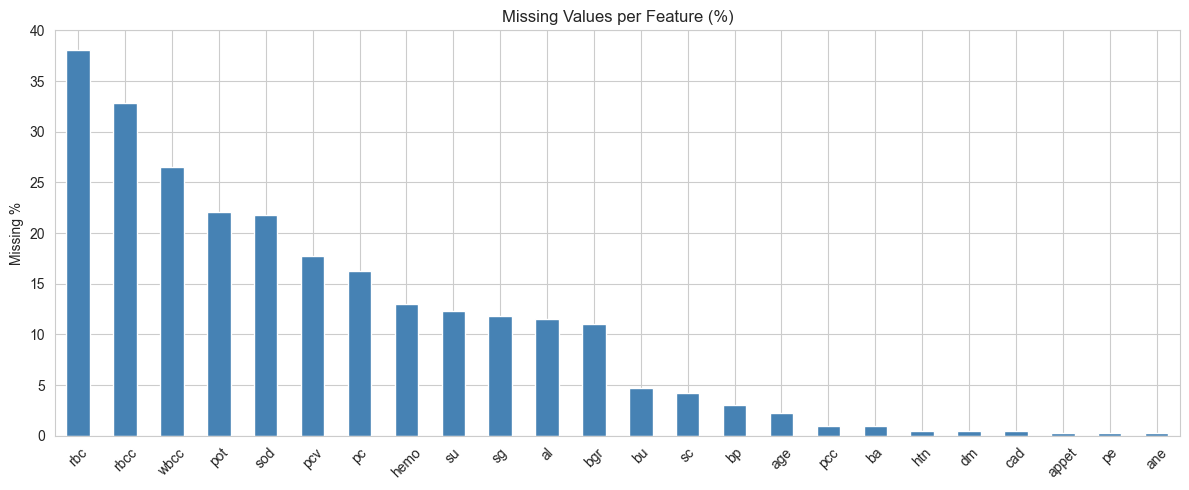

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)

plt.figure(figsize=(12, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue')
plt.title('Missing Values per Feature (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../report/missing_values.png', dpi=150)
plt.show()

=== Class Distribution ===
class
ckd       250
notckd    149
Name: count, dtype: int64

Percentage:
class
ckd       62.66
notckd    37.34
Name: proportion, dtype: float64


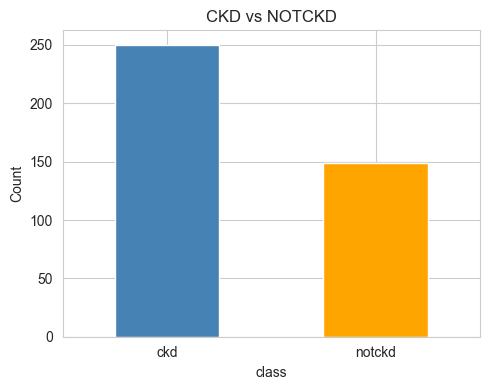

In [7]:
print("=== Class Distribution ===")
print(df['class'].value_counts())
print("\nPercentage:")
print(df['class'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(5, 4))
df['class'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('CKD vs NOTCKD')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/class_distribution.png', dpi=150)
plt.show()

Numeric columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']


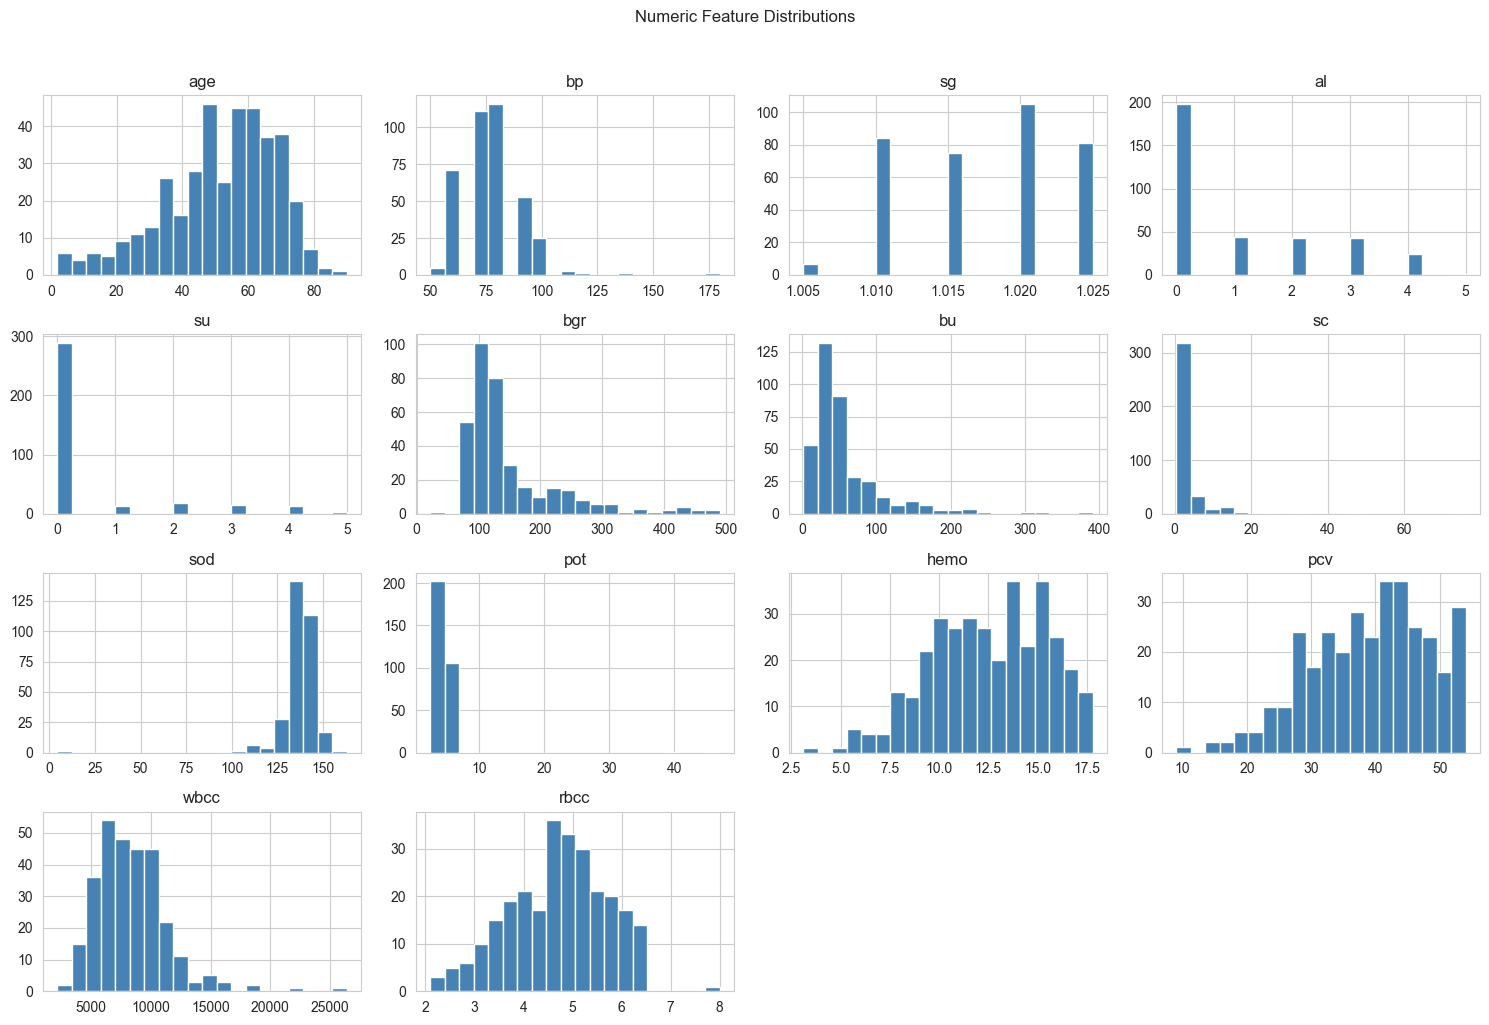

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)

df[numeric_cols].hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('../report/numeric_distributions.png', dpi=150)
plt.show()

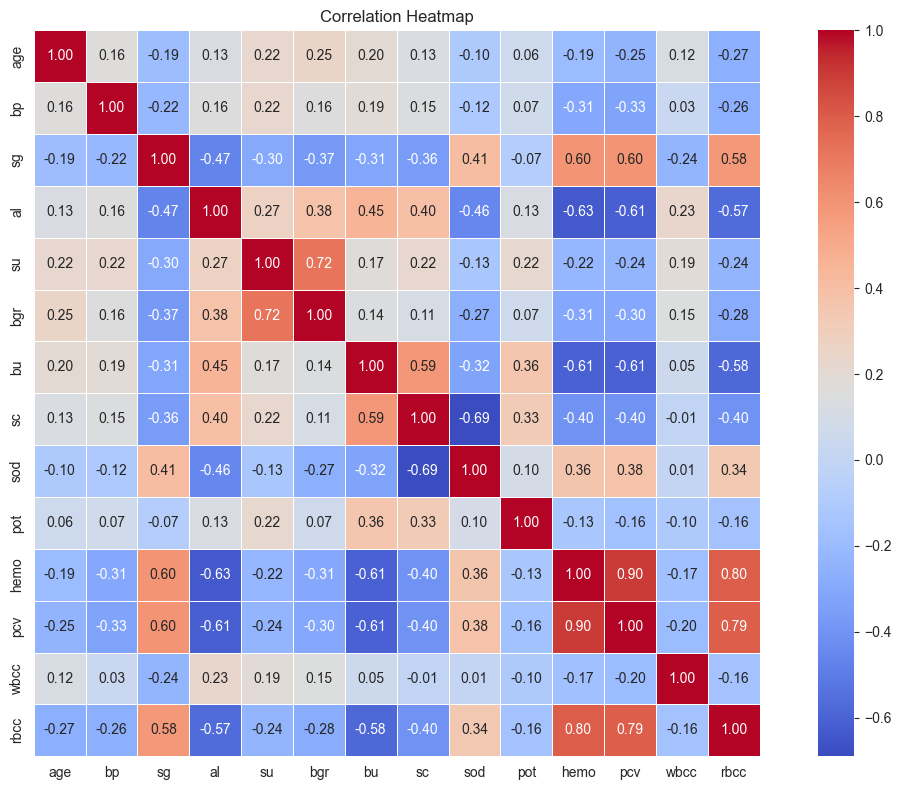

In [9]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150)
plt.show()

Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


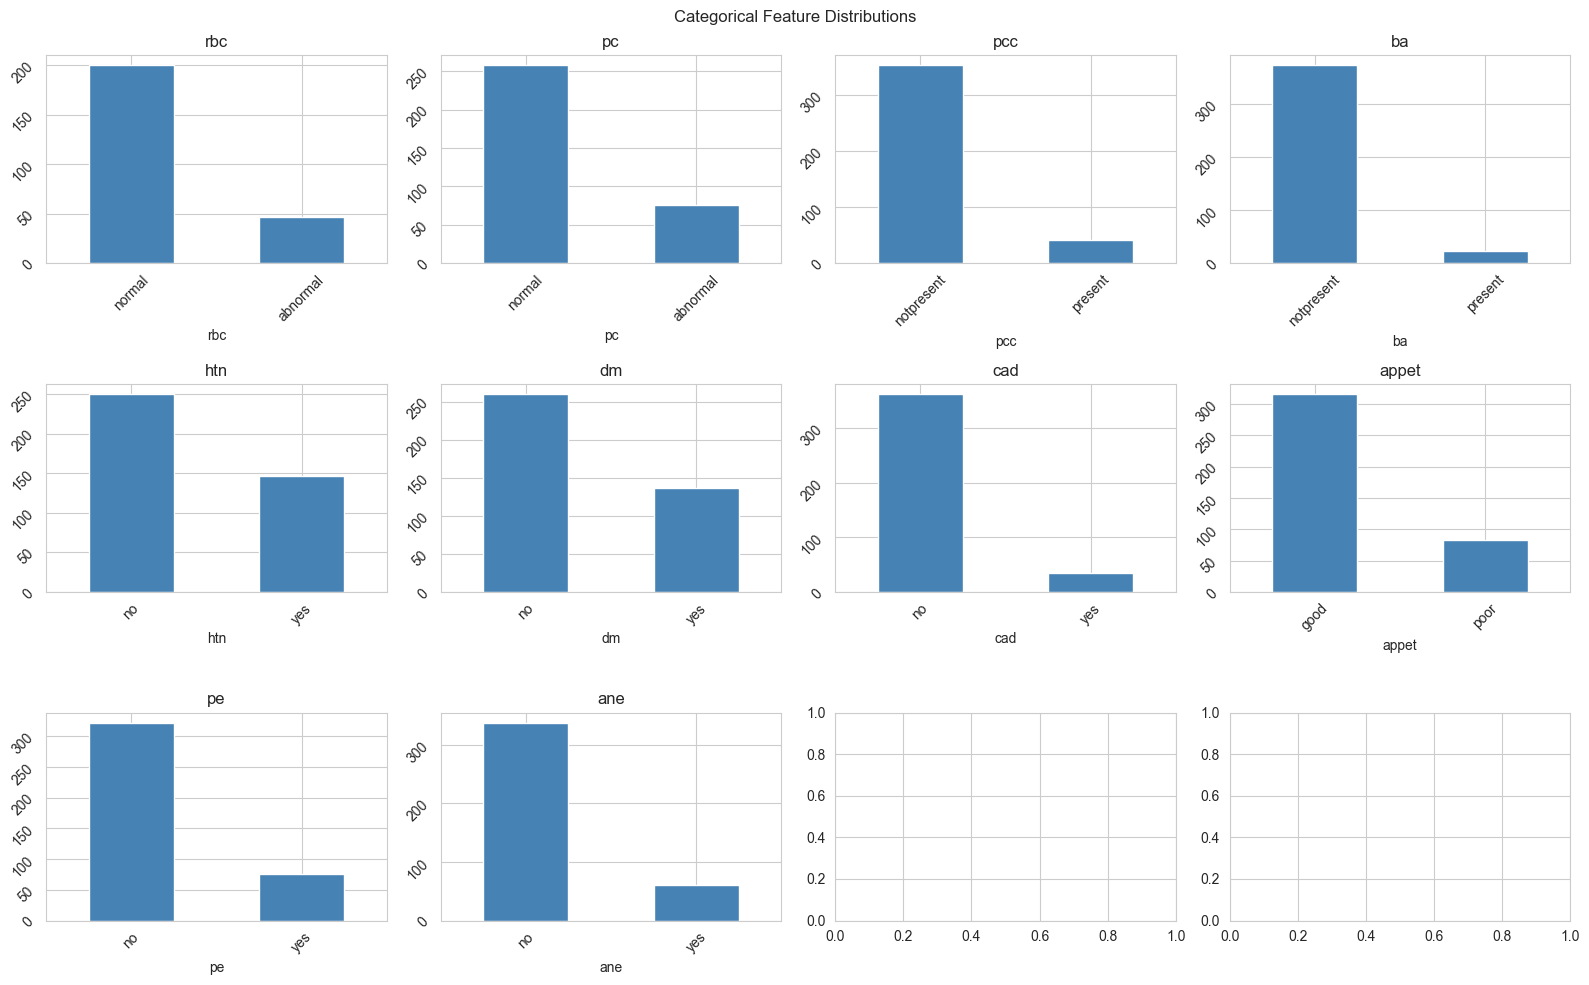

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'class']
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(rotation=45)

plt.suptitle('Categorical Feature Distributions')
plt.tight_layout()
plt.savefig('../report/categorical_features.png', dpi=150)
plt.show()

## Key EDA Findings

- **Dataset:** 399 rows, 25 columns (24 features + 1 target)
- **Class Imbalance:** ~62.5% CKD, ~37.5% NOTCKD
- **Missing Values:** Multiple columns have missing data (max ~38% in rbcc)
- **Numeric Features:** 14 numeric, 10 categorical
- **Key Correlations:** hemo, pcv, rbcc strongly correlated with each other
- **Preprocessing Needed:** Imputation, encoding, scaling, class balancing